# Tarea Nº 3 — Inteligencia Artificial

**Estudiante:** Maximiliano Solorza  
**Fecha de entrega:** Domingo 28 de Junio de 2026

In [53]:
# === instalacion librerias necesarias === #
#!pip install numpy pandas matplotlib pgmpy ipywidgets seaborn scikit-learn tensorflow imbalanced-learn tf-keras
%pip install numpy pandas matplotlib pgmpy ipywidgets seaborn scikit-learn tensorflow imbalanced-learn tf-keras
# ======================================== #

Note: you may need to restart the kernel to use updated packages.


In [54]:
# =================== dependencias del proyecto ==================== #
import os

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import sklearn as sk
import tf_keras as keras
from tf_keras import layers, regularizers


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score,
                             precision_score, recall_score,
                             classification_report, confusion_matrix)
# ================================================================== #

In [55]:
# ===== fijacion de semillas ===== #
SixSeven = 67 
random.seed(SixSeven)
np.random.seed(SixSeven)
tf.random.set_seed(SixSeven)
# ================================ #

In [56]:
# ============ estilo de los graficos ============ #
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
# ================================================ #

In [57]:
# ======= chequeo de versiones ======= #
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("TensorFlow:", tf.__version__)
print("scikit-learn:", sk.__version__)
print("Semilla fijada en:", SixSeven)
# ==================================== #

numpy: 2.5.0
pandas: 3.0.4
TensorFlow: 2.21.0
scikit-learn: 1.9.0
Semilla fijada en: 67


In [58]:
# ======================== carga de los dataset ======================== #
base = "datasets/"

dataframes = {
    "Balanceado":    os.path.join(base, "postures_balanced_50000.csv"),
    "Desbalanceado": os.path.join(base, "postures_imbalanced_50000.csv"),
}

raw = {name: pd.read_csv(path) for name, path in dataframes.items()}

for name, df in raw.items():
    print(f"° {name}, shape: {df.shape}")

print("\nPrimeras filas (Balanceado):")
display(raw["Balanceado"].head())

print("\nPrimeras filas (Desbalanceado):")
display(raw["Desbalanceado"].head())
# ====================================================================== #

° Balanceado, shape: (50000, 23)
° Desbalanceado, shape: (50000, 23)

Primeras filas (Balanceado):


,Class,User,X0,Y0,Z0,X1,Y1,Z1,X2,Y2,...,Z3,X4,Y4,Z4,X5,Y5,Z5,X6,Y6,Z6
0,4,12,61.947275,135.407496,-20.554474,38.682137,89.049858,-8.439905,46.700389,150.469101,...,-30.455520,62.332455,81.884850,-19.691140,45.159813,17.067704,-79.308088,NaN,NaN,NaN
1,1,13,62.799492,50.736675,-68.975138,56.338217,77.474460,-64.680418,59.656012,17.462805,...,-45.737813,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1,31.487777,85.870298,-47.904666,-10.991409,80.020112,-40.783903,12.858542,83.661513,...,-54.680505,61.226931,56.960649,-59.567917,NaN,NaN,NaN,NaN,NaN,NaN
3,2,14,68.744593,139.890999,8.297129,88.666925,75.668980,-42.573109,0.882151,121.883681,...,-6.692044,16.391990,93.505650,16.652949,73.089022,57.978044,-46.237332,21.047267,140.854416,39.985918
4,4,13,43.607745,144.183804,11.788656,61.446513,135.027272,3.987780,82.103598,74.991998,...,3.191450,58.724120,94.983372,-0.770625,65.004897,18.997488,-57.759273,77.840263,49.234491,-57.326648



Primeras filas (Desbalanceado):


,Class,User,X0,Y0,Z0,X1,Y1,Z1,X2,Y2,...,Z3,X4,Y4,Z4,X5,Y5,Z5,X6,Y6,Z6
0,3,8,27.223664,81.749158,-51.329624,105.730511,19.628531,-92.542984,58.585362,137.272136,...,-34.421747,82.600168,14.240770,-90.563749,3.731535,82.396533,-44.331580,60.300927,-6.138673,-78.992701
1,1,13,62.799492,50.736675,-68.975138,56.338217,77.474460,-64.680418,59.656012,17.462805,...,-45.737813,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1,31.487777,85.870298,-47.904666,-10.991409,80.020112,-40.783903,12.858542,83.661513,...,-54.680505,61.226931,56.960649,-59.567917,NaN,NaN,NaN,NaN,NaN,NaN
3,1,12,69.731431,68.097701,-48.749863,-10.081609,82.377167,-35.627840,46.762607,9.792311,...,-38.051597,43.151214,78.818724,-43.225743,46.142755,49.030409,-95.980369,NaN,NaN,NaN
4,3,11,52.475086,93.050853,7.763829,49.576891,132.613513,17.422233,74.386492,17.077776,...,-50.050866,116.092302,47.785267,-48.935800,11.588880,87.100435,-27.528267,NaN,NaN,NaN


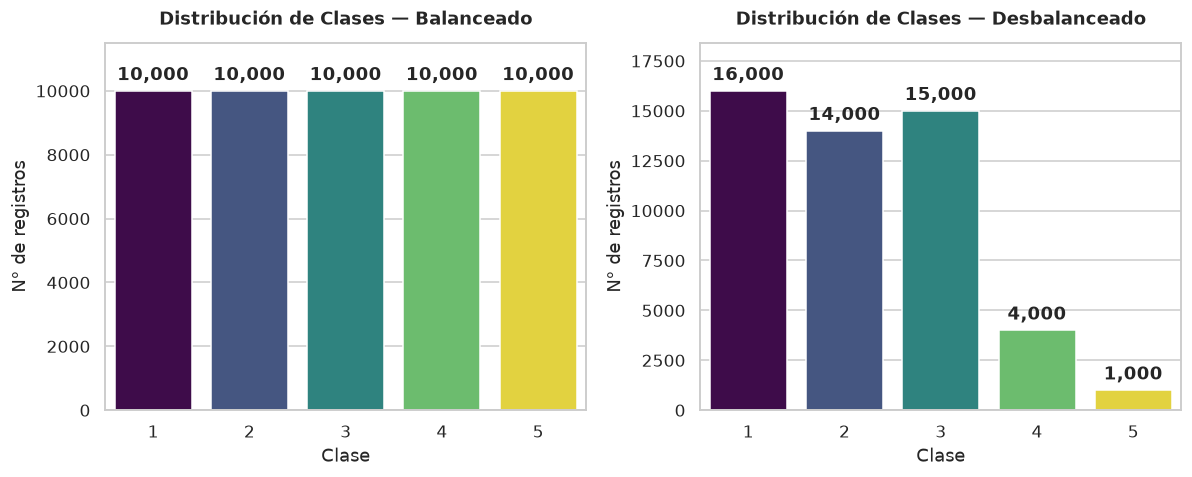

Proporciones por clase:


,Balanceado,Desbalanceado
Clase,,
1,20.00%,32.00%
2,20.00%,28.00%
3,20.00%,30.00%
4,20.00%,8.00%
5,20.00%,2.00%


In [59]:
# ===================== graficos para revisar la distribución ===================== #
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (name, df) in zip(axes, raw.items()):
    counts = df["Class"].value_counts().sort_index()
    
    sns.barplot(
        x=counts.index, 
        y=counts.values, 
        ax=ax, 
        hue=counts.index,
        palette="viridis", 
        legend=False
    )
    
    ax.set_title(f"Distribución de Clases — {name}", pad=12, fontweight="bold")
    ax.set_xlabel("Clase")
    ax.set_ylabel("N° de registros")
    ax.set_ylim(0, max(counts.values) * 1.15) 
    
    for i, v in enumerate(counts.values):
        ax.text(
            x=i, 
            y=v + (max(counts.values) * 0.02), 
            s=f"{v:,}", 
            ha="center", 
            va="bottom",
            fontweight="bold"
        )

plt.tight_layout()
plt.show()
# ================================================================================= #

# ============================ proporciones por clase ============================= #
prop = pd.DataFrame({
    name: df["Class"].value_counts(normalize=True).sort_index()
    for name, df in raw.items()
})
prop.index.name = "Clase"

print("Proporciones por clase:")
display(prop.style.format("{:.2%}").background_gradient(cmap="Blues", axis=0))
# ================================================================================= #

Se graficaron ambos datasets para conocer realmente la distribución interna de estos, como se esperaba, el dataset balanceado presenta la misma cantidad de ejemplos para cada clase presente en el dataset.

Por otro lado, en el dataset desbalanceado se aprecia que las clases 1-3 representan el 90% de los ejemplos, por lo cual se deben tomar más precauciones al trabajar con este dataset. Esto porque si usamos un parámetro de validación como el accuracy, este podría tener un valor alto cumpliendo con estándares como el 90%, pero será engañoso en el peor de los casos, ese 90% puede significar que las clases 1-3 son clasificadas correctamente dejando 2 clases sin clasificar, lo cual nos da esa sensación de algo bien logrado, pero en la práctica 2 clases completas sin una correcta clasificación no deberían aceptarse, ya que el modelo estaría sufriendo el sesgo de la mayoría.

Posterior a las consideraciones tomadas, antes de proceder se debe normalizar el dataset, ya que se encuentran varios features dentro de un mismo ejemplo con NaN. Por lo tanto, se verá el impacto de eliminar estos ejemplos.

In [60]:
# ================================ análisis de valores faltantes (NaN) =============================== #
feat_cols = [c for c in raw["Balanceado"].columns if c not in ("Class", "User")]

na_table = pd.DataFrame({
    "Cant_Balanceado": raw["Balanceado"][feat_cols].isna().sum(),
    "Cant_Desbalanceado": raw["Desbalanceado"][feat_cols].isna().sum()
})

na_table["%_Balanceado"] = (
    na_table["Cant_Balanceado"] / len(raw["Balanceado"]) * 100).round(2)

na_table["%_Desbalanceado"] = (
    na_table["Cant_Desbalanceado"] / len(raw["Desbalanceado"]) * 100).round(2)

column_order = ["Cant_Balanceado",
                "%_Balanceado",
                "Cant_Desbalanceado",
                "%_Desbalanceado"]

na_table = na_table[column_order]

variables_con_nan = na_table[(na_table["Cant_Balanceado"] + na_table["Cant_Desbalanceado"]) > 0]

print("Valores faltantes detallados por variable:")

display(
    variables_con_nan.style
    .format({"%_Balanceado": "{:.2f}%",
             "%_Desbalanceado": "{:.2f}%", 
             "Cant_Balanceado": "{:,}",
             "Cant_Desbalanceado": "{:,}"})
    .background_gradient(cmap="Reds", subset=["%_Balanceado", "%_Desbalanceado"])
)

print("Impacto total a nivel de filas (muestras incompletas):")

for name, df in raw.items():
    filas_incompletas = df[feat_cols].isna().any(axis=1).sum()
    porcentaje_total = (filas_incompletas / len(df)) * 100
    
    print(f"  ° {name:<14}: {filas_incompletas:,} filas afectadas ({porcentaje_total:.2f}%)")
# ==================================================================================================== #

Valores faltantes detallados por variable:


,Cant_Balanceado,%_Balanceado,Cant_Desbalanceado,%_Desbalanceado
X3,417,0.83%,670,1.34%
Y3,417,0.83%,670,1.34%
Z3,417,0.83%,670,1.34%
X4,"1,862",3.72%,"2,932",5.86%
Y4,"1,862",3.72%,"2,932",5.86%
Z4,"1,862",3.72%,"2,932",5.86%
X5,"7,926",15.85%,"12,219",24.44%
Y5,"7,926",15.85%,"12,219",24.44%
Z5,"7,926",15.85%,"12,219",24.44%
X6,"15,869",31.74%,"23,171",46.34%


Impacto total a nivel de filas (muestras incompletas):
  ° Balanceado    : 15,869 filas afectadas (31.74%)
  ° Desbalanceado : 23,171 filas afectadas (46.34%)


En la tabla anterior se puede apreciar que ambos datasets tienen algunas features vacías. Ambos tienen la misma distribución, es decir los sensores 0 al 2 funcionan perfectamente ya que no aparecen en la tabla, por otro lado las features (sensores del 3 al 4) tienen un porcentaje de pérdida menor que va incrementando hasta los sensores 6, con una pérdida mayor de 30-40% aprox.

Dada la alta cantidad de missing values, eliminar las filas con NaN (usando comandos como dropna()) sería un error metodológico devastador, ya que destruiría el $31.74\%$ del dataset balanceado y casi la mitad ($46.34\%$) del desbalanceado. Borrar filas en ese dataset podría reducir drásticamente los pocos registros existentes de la Clase 5 ($2\%$), o de cualquier clase, ya que las 23k de filas afectadas superan la cantidad de ejemplos de cualquier clase del desbalanceado.

Una buena opción para esta distribución interna sería SimpleImputer, ya que se preservarán todas las filas rellenando los NaN mediante la mediana de cada columna, una métrica central que, a diferencia de la media, no se ve afectada por valores atípicos (outliers) causados por fallas en los sensores.



In [61]:
TARGET = "Class"
ID_COL = "User"
N_CLASSES = 5
CLASS_NAMES = [f"Clase {i}" for i in range(1, N_CLASSES + 1)]

def preparar_dataset(df, seed=SixSeven):
    y = df[TARGET].values - 1                        
    X = df.drop(columns=[TARGET, ID_COL]).values

    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        X, y, test_size=0.40, stratify=y, random_state=seed)
    X_val, X_te, y_val, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=seed)

    imputer = SimpleImputer(strategy="median").fit(X_tr)
    scaler  = StandardScaler().fit(imputer.transform(X_tr))
    tf_ = lambda Z: scaler.transform(imputer.transform(Z))

    return {
        "X_tr": tf_(X_tr),  "y_tr": y_tr,
        "X_val": tf_(X_val), "y_val": y_val,
        "X_te": tf_(X_te),  "y_te": y_te,
        "imputer": imputer, "scaler": scaler,
        "n_features": X_tr.shape[1],
    }

splits = {name: preparar_dataset(df) for name, df in raw.items()}


for name, s in splits.items():
    print(f"=== {name} ===")
    for part in ["tr", "val", "te"]:
        y = s[f"y_{part}"]
        dist = np.bincount(y, minlength=N_CLASSES)
        print(f"  {part:3s}: {len(y):6d} muestras | clases {dict(enumerate(dist, start=1))}")

=== Balanceado ===
  tr :  30000 muestras | clases {1: np.int64(6000), 2: np.int64(6000), 3: np.int64(6000), 4: np.int64(6000), 5: np.int64(6000)}
  val:  10000 muestras | clases {1: np.int64(2000), 2: np.int64(2000), 3: np.int64(2000), 4: np.int64(2000), 5: np.int64(2000)}
  te :  10000 muestras | clases {1: np.int64(2000), 2: np.int64(2000), 3: np.int64(2000), 4: np.int64(2000), 5: np.int64(2000)}
=== Desbalanceado ===
  tr :  30000 muestras | clases {1: np.int64(9600), 2: np.int64(8400), 3: np.int64(9000), 4: np.int64(2400), 5: np.int64(600)}
  val:  10000 muestras | clases {1: np.int64(3200), 2: np.int64(2800), 3: np.int64(3000), 4: np.int64(800), 5: np.int64(200)}
  te :  10000 muestras | clases {1: np.int64(3200), 2: np.int64(2800), 3: np.int64(3000), 4: np.int64(800), 5: np.int64(200)}


ya separado el dataset siguiendo la distribucion de clases para un correcto entrenamiento, esta todo listo para definir las **cuatro arquitecturas distintas** (número de capas, neuronas por capa, función de activación,*optimizer*, *learning rate*, *batch size* y regularización mediante *Dropout* y/o L2)

Una vez decididas las arquitecturas estas se mantendran paralelamente tanto para el dataset balanceado como el desbalanceado, asi poder comparar tanto arquitectura como distribucion interna del dataset

Arquitecturas definidas:

| Arq. | Capas ocultas | Activación | Optimizer (lr) | Batch | Regularización |
|------|---------------|-----------|----------------|-------|----------------|
| **A** (base)    | [64]            | ReLU | Adam (1e-3) | 128 | — |
| **B** (profunda)| [128, 64, 32]   | ReLU | Adam (1e-3) | 256 | Dropout 0.3 |
| **C** (ancha+L2)| [256, 128]      | tanh | Adam (5e-4) | 256 | L2 1e-4 |
| **D** (SGD)     | [128, 64]       | ReLU | SGD m=0.9 (1e-2) | 64 | Dropout 0.2 |

- **A (base):** es la red más simple posible con una sola capa oculta, sin regularizacion, lo que se espera que para las clases pequeñas pueda tener overfitting, ademas con Adam a 1e-3, que es el learning rate standar 0.001.

- **B (profunda):** apila 3 capas ocultas (128, 64 y 32), teniendo mayor capacidad en las capas principales y luego esta disminucion de neuronas en las capas va resumiendo la información, esta tiene regularrización *Dropout* 0.3 para que tanta capacidad no se aprenda los datos de memoria evitando overfitting.

- **C (ancha + L2):** para el tercer modelo mi intencion es comparar basicamente el performance entre profundidad(cantidad de capas) vs ancho: mas neuronas por capa. otro cambio es el uso de **tanh** en vez de ReLU, para ver como se comporta tanh en este caso y si su forma de S afecta al actualizar parametros, dado que con valores muy altos o bajos esta puede estancar sus parametros por la baja pendiente (segun la teoria), fianlmente en este caso y regularizo con **L2** en vez de *Dropout*.

- **D (SGD):** lo que cambia principalmente es el **optimizador**: SGD con momentum en lugar de Adam, y con *batch* chico (64), que hace el entrenamiento más ruidoso pudiendo ayudar a generalizar mejor ya que no se adapta tanto a los datos de entrenamiento.

Todas usan salida `softmax` (5 neuronas) y `sparse_categorical_crossentropy`.

In [ ]:
def construir_mlp(input_dim, n_classes, hidden, activation, dropout, l2, optimizer, lr):

    model = keras.Sequential(name="MLP")
    model.add(keras.Input(shape=(input_dim,)))
    reg = regularizers.l2(l2) if l2 and l2 > 0 else None
    for h in hidden:
        model.add(layers.Dense(h, activation=activation, kernel_regularizer=reg))
        if dropout and dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(n_classes, activation="softmax"))

    if optimizer == "adam":
        opt = keras.optimizers.Adam(learning_rate=lr)
    else:
        opt = keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


ARQUITECTURAS = [
    dict(nombre="A",  hidden=[64],          activation="relu", dropout=0.0, l2=0.0,
         optimizer="adam", lr=1e-3, batch_size=128),
    dict(nombre="B",  hidden=[128, 64, 32], activation="relu", dropout=0.3, l2=0.0,
         optimizer="adam", lr=1e-3, batch_size=256),
    dict(nombre="C",  hidden=[256, 128],    activation="tanh", dropout=0.0, l2=1e-4,
         optimizer="adam", lr=5e-4, batch_size=256),
    dict(nombre="D",  hidden=[128, 64],     activation="relu", dropout=0.2, l2=0.0,
         optimizer="sgd",  lr=1e-2, batch_size=64),
]

EPOCHS = 80
print(f"{len(ARQUITECTURAS)} arquitecturas definidas. Épocas máximas: {EPOCHS}")

4 arquitecturas definidas. Épocas máximas: 80


In [ ]:
def entrenar(config, s, epochs=EPOCHS, class_weight=None, verbose=0):

    model = construir_mlp(s["n_features"], N_CLASSES, config["hidden"], config["activation"],
                          config["dropout"], config["l2"], config["optimizer"], config["lr"])
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10,
                                       restore_best_weights=True)
    hist = model.fit(s["X_tr"], s["y_tr"],
                     validation_data=(s["X_val"], s["y_val"]),
                     epochs=epochs, batch_size=config["batch_size"],
                     callbacks=[es], class_weight=class_weight, verbose=verbose)
    return model, hist


modelos    = {}   
historiales = {} 
filas_resumen = []

for dname, s in splits.items():
    print(f"\n############ Dataset: {dname} ############")
    for cfg in ARQUITECTURAS:
        keras.utils.set_random_seed(SixSeven)
        model, hist = entrenar(cfg, s)
        key = (dname, cfg["nombre"])
        modelos[key] = model
        historiales[key] = hist.history

        y_val_pred = model.predict(s["X_val"], verbose=0).argmax(axis=1)
        val_acc = accuracy_score(s["y_val"], y_val_pred)
        val_f1  = f1_score(s["y_val"], y_val_pred, average="macro")
        ep = len(hist.history["loss"])

        filas_resumen.append(dict(
            Dataset=dname, Arq=cfg["nombre"],
            Capas=str(cfg["hidden"]), Activacion=cfg["activation"],
            Optimizer=cfg["optimizer"], LR=cfg["lr"], Batch=cfg["batch_size"],
            Dropout=cfg["dropout"], L2=cfg["l2"],
            Epocas=ep, Val_Accuracy=round(val_acc, 4), Val_F1_macro=round(val_f1, 4)))
        print(f"  Arq {cfg['nombre']:2s} | épocas={ep:2d} | "
              f"val_acc={val_acc:.4f} | val_F1_macro={val_f1:.4f}")

print("\nEntrenamiento completo.")


############ Dataset: Balanceado ############
  Arq A  | épocas=80 | val_acc=0.9325 | val_F1_macro=0.9323
  Arq B  | épocas=80 | val_acc=0.9659 | val_F1_macro=0.9658
  Arq C  | épocas=80 | val_acc=0.9559 | val_F1_macro=0.9559
  Arq D  | épocas=80 | val_acc=0.9728 | val_F1_macro=0.9727

############ Dataset: Desbalanceado ############
  Arq A  | épocas=80 | val_acc=0.9484 | val_F1_macro=0.8847
  Arq B  | épocas=80 | val_acc=0.9641 | val_F1_macro=0.9203
  Arq C  | épocas=80 | val_acc=0.9633 | val_F1_macro=0.9088
  Arq D  | épocas=80 | val_acc=0.9702 | val_F1_macro=0.9313

Entrenamiento completo.


Análisis comparativo de las 4 arquitecturas

**1.** Primeras impresiones: en ambos casos la red mas simple con solo 1 capa oculta fue la de peor desempeño, lo que confirma que una única capa es insuficiente para clasificar correctamente, ademas indica fuertemente que son necesarias mas capas, en ambos casos es seguida de la arquitectura C con la funcion de activacion tanh, en este caso no puedo concluir con certeza si tanh es la principal responsable ya que difiere en mas que solo la funcion de activacion con las otras redes, pero puedo inferir que usar tanh no me da ventaja o que no es tan determinista para este problema.

**2.** La arquitectura D es la más robusta en ambos escenarios, con las capas [128, 64], ReLU, *Dropout* 0.2 y SGD con *momentum* (lr=1e-2, batch 64), D obtiene el mejor F1-macro tanto en el balanceado (0.9727) como en el desbalanceado (0.9313).

**3.** La diferencia entre Accuracy y F1-macro hace notorio el desbalance. En el dataset balanceado ambas métricas coinciden casi exactamente ya que la distribución uniforme hace que promediar por clase o por muestra dé lo mismo. En el desbalanceado en cambio el Accuracy infla el resultado: la arquitectura A pasa de un aparente 94.84% de Accuracy a solo 0.8847 de F1-macro, una brecha de ~6 puntos. Es exactamente el "Accuracy mentiroso" que se predijo: el modelo acierta las clases mayoritarias (1-3) y el promedio macro castiga su debilidad en las minoritarias (4-5).

**4.** Las redes con mas capas y *Dropout* (D y B) le ganaron a la red ancha con tanh y L2 (C), para este problema parece que el *Dropout* regulariza mejor que L2, aunque tampoco puedo aislar si es el Dropout solo o la combinacion con la profundidad lo que marca la diferencia.

Notas: 

Puedo concluir con certeza que de las arquitecturas seleccionadas el combo D fue el 
mas robusto, pero para determinar qué elementos fueron los determinantes se debería tomar 
una arquitectura de ancla e ir modificando de a un hiperparámetro a la vez, eso se llama 
ablation study.

Para garantizar reproducibilidad se fijó una semilla global (`SixSeven = 67`) en numpy, 
random y TensorFlow. Esto asegura que los pesos iniciales de cada red, el orden de los 
datos y cualquier operación aleatoria sean idénticos en cada ejecución, de modo que si 
un modelo obtiene mejor resultado se debe a su arquitectura y no a una inicialización 
favorable por azar.

---
## 2. Selección del mejor modelo y evaluación en el conjunto de prueba

In [75]:
mejores = {}
for dname in splits:
    cand = resumen[resumen["Dataset"] == dname]
    best_arq = cand.loc[cand["Val_F1_macro"].idxmax(), "Arq"]
    mejores[dname] = best_arq
    print(f"Mejor arquitectura en {dname}: Arq {best_arq} "
          f"(val_F1_macro = {cand['Val_F1_macro'].max():.4f})")

Mejor arquitectura en Balanceado: Arq D (val_F1_macro = 0.9727)
Mejor arquitectura en Desbalanceado: Arq D (val_F1_macro = 0.9313)



Aplicando el criterio de **F1-macro en validación**, la **arquitectura D resulta ganadora en ambos *datasets*** (0.9727 en el balanceado y 0.9313 en el desbalanceado). Que la misma arquitectura sea la mejor en las 2 distribuciones refuerza que la combinacion es robusta.

El F1-macro fue el criterio elegido por una razon bien simple: pondera por igual a las 5 clases, de modo que un modelo no puede "ganar" simplemente acertando las clases mayoritarias.

In [ ]:
def evaluar_en_test(dname, arq):
    s = splits[dname]
    model = modelos[(dname, arq)]
    y_pred = model.predict(s["X_te"], verbose=0).argmax(axis=1)
    y_true = s["y_te"]
    return dict(
        accuracy   = accuracy_score(y_true, y_pred),
        f1_macro   = f1_score(y_true, y_pred, average="macro"),
        f1_weighted= f1_score(y_true, y_pred, average="weighted"),
        prec_macro = precision_score(y_true, y_pred, average="macro", zero_division=0),
        rec_macro  = recall_score(y_true, y_pred, average="macro"),
        y_true=y_true, y_pred=y_pred)

test_res = {dname: evaluar_en_test(dname, arq) for dname, arq in mejores.items()}

tabla_test = pd.DataFrame({
    dname: {k: round(v, 4) for k, v in r.items() if k not in ("y_true", "y_pred")}
    for dname, r in test_res.items()}).T
tabla_test.index.name = "Dataset (modelo final)"
print("Desempeño en el conjunto de PRUEBA:")
tabla_test

Desempeño en el conjunto de PRUEBA:


,accuracy,f1_macro,f1_weighted,prec_macro,rec_macro
Dataset (modelo final),,,,,
Balanceado,0.9728,0.9728,0.9728,0.9729,0.9728
Desbalanceado,0.9720,0.9368,0.9716,0.9523,0.9231


In [ ]:
for dname, r in test_res.items():
    print(f"\n===== Reporte de clasificación — {dname} (Arq {mejores[dname]}) — TEST =====")
    print(classification_report(r["y_true"], r["y_pred"],
                                target_names=CLASS_NAMES, digits=4, zero_division=0))


===== Reporte de clasificación — Balanceado (Arq D) — TEST =====
              precision    recall  f1-score   support

     Clase 1     0.9955    0.9955    0.9955      2000
     Clase 2     0.9757    0.9445    0.9599      2000
     Clase 3     0.9554    0.9850    0.9700      2000
     Clase 4     0.9627    0.9560    0.9594      2000
     Clase 5     0.9752    0.9830    0.9791      2000

    accuracy                         0.9728     10000
   macro avg     0.9729    0.9728    0.9728     10000
weighted avg     0.9729    0.9728    0.9728     10000


===== Reporte de clasificación — Desbalanceado (Arq D) — TEST =====
              precision    recall  f1-score   support

     Clase 1     0.9950    0.9959    0.9955      3200
     Clase 2     0.9696    0.9693    0.9695      2800
     Clase 3     0.9646    0.9890    0.9766      3000
     Clase 4     0.9290    0.8662    0.8965       800
     Clase 5     0.9034    0.7950    0.8457       200

    accuracy                         0.9720     10

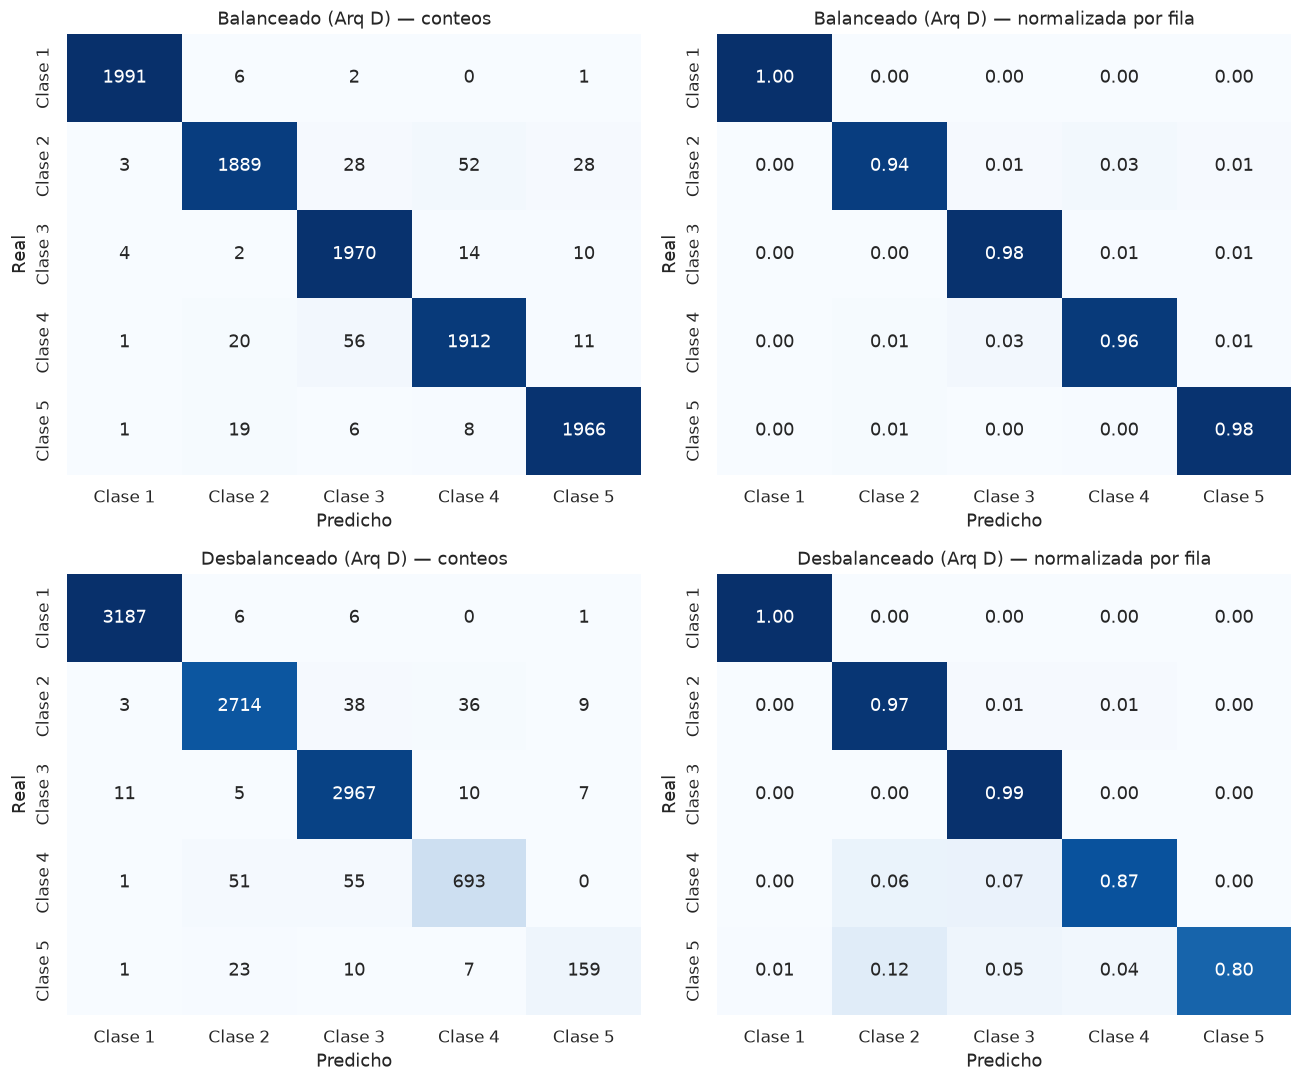

In [68]:
# ----- Matrices de confusión (conteo y normalizada por fila) -----
fig, axes = plt.subplots(len(test_res), 2, figsize=(12, 5 * len(test_res)))
for row, (dname, r) in enumerate(test_res.items()):
    cm = confusion_matrix(r["y_true"], r["y_pred"])
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    for col, (M, fmt, titulo) in enumerate([(cm, "d", "conteos"),
                                            (cm_norm, ".2f", "normalizada por fila")]):
        ax = axes[row, col] if len(test_res) > 1 else axes[col]
        sns.heatmap(M, annot=True, fmt=fmt, cmap="Blues", cbar=False,
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
        ax.set_title(f"{dname} (Arq {mejores[dname]}) — {titulo}")
        ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
plt.tight_layout(); plt.show()

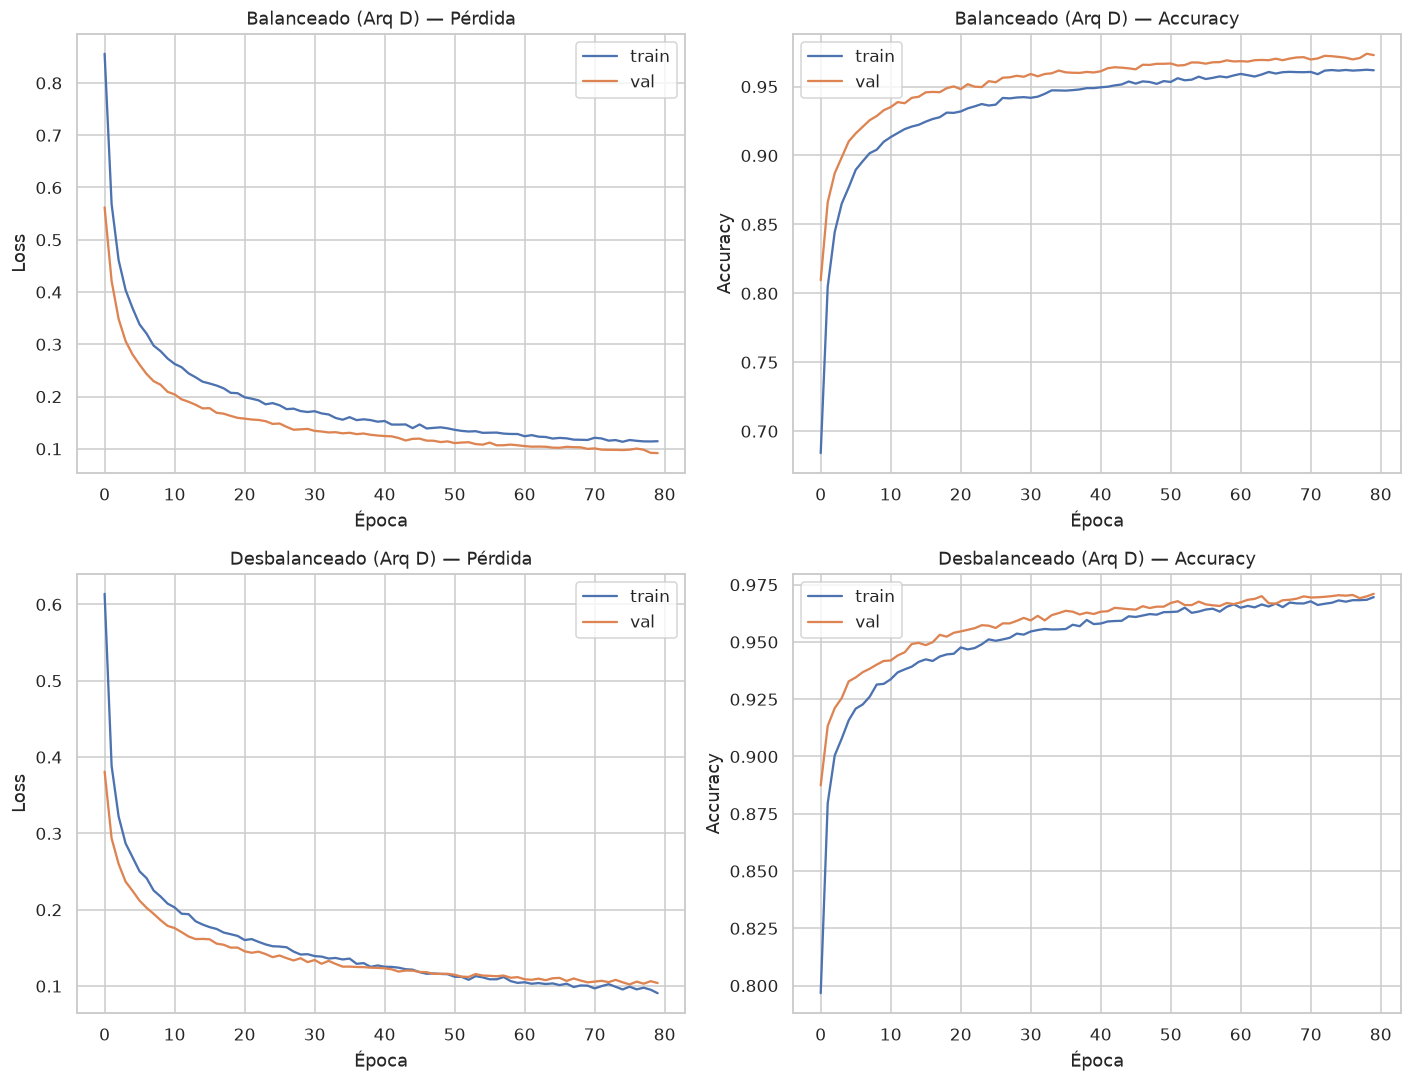

In [69]:
# ----- Curvas de entrenamiento y validación por época (modelos finales) -----
fig, axes = plt.subplots(len(test_res), 2, figsize=(13, 5 * len(test_res)))
for row, dname in enumerate(mejores):
    h = historiales[(dname, mejores[dname])]
    ejes = axes[row] if len(test_res) > 1 else axes
    # Pérdida
    ejes[0].plot(h["loss"], label="train")
    ejes[0].plot(h["val_loss"], label="val")
    ejes[0].set_title(f"{dname} (Arq {mejores[dname]}) — Pérdida")
    ejes[0].set_xlabel("Época"); ejes[0].set_ylabel("Loss"); ejes[0].legend()
    # Accuracy
    ejes[1].plot(h["accuracy"], label="train")
    ejes[1].plot(h["val_accuracy"], label="val")
    ejes[1].set_title(f"{dname} (Arq {mejores[dname]}) — Accuracy")
    ejes[1].set_xlabel("Época"); ejes[1].set_ylabel("Accuracy"); ejes[1].legend()
plt.tight_layout(); plt.show()

### Curvas de entrenamiento

Lo primero que se aprecia en ambos casos es que las curvas de train y val se acompañan 
de cerca durante todo el entrenamiento, esto es una buena señal ya que significa que el 
modelo no esta memorizando los datos de entrenamiento, si hubiera overfitting se veria 
que la perdida de train sigue bajando pero la de val empieza a subir, eso no pasa aca.

La forma de las curvas tambien dice bastante: la caida es muy pronunciada en las primeras 
epocas (~10) y luego se va aplanando, esto es esperable ya que al principio el modelo 
aprende rapido porque parte desde cero y hay mucho margen de mejora, despues los avances 
son mas finos y costosos.

Un detalle interesante en ambas distribuciones,la curva de validacion esta levemente por encima 
de la de train en accuracy (val mejor que train), esto se debe a que la combinacion ganadora usa Dropout, el cual solo se activa durante el entrenamiento, entonces durante validacion todas las neuronas estan activas y el modelo rinde un poco mejor que en train donde se apagan neuronas al azar.

Finalmente que ninguno de los 2 haya activado el early stopping (llegaron a las 80 epocas) 
indica que el modelo seguia mejorando hasta el final sin estancarse, lo que podria sugerir 
que con mas epocas podria mejorar un poco mas, aunque los saltos ya serian minimos dado 
lo plano de la curva al final(dado la teoria).

---
## 3. Modelo de menor desempeño: análisis y mejora


El modelo de menor desempeño es el **Desbalanceado (Arq D)** con F1-macro 0.9368, 
lo interesante es que D fue la mejor arquitectura disponible para ese dataset, o sea 
el problema no es la red sino los datos con los que tuvo que trabajar.

Por eso la estrategia de mejora mantiene exactamente la misma arquitectura D y ataca 
directamente el desbalance, ya que cambiar la red no tendria sentido si el cuello de 
botella son los datos.

### 3.1 Modificación propuesta: ponderación de clases (*class weights*)

Como modificación se **reentrena exactamente la misma arquitectura** del modelo de menor
desempeño, pero añadiendo **pesos por clase** inversamente proporcionales a su frecuencia
(`class_weight='balanced'`). Así, los errores en clases minoritarias penalizan más durante el
entrenamiento, sin alterar la partición ni el conjunto de prueba (la comparación es justa).


In [ ]:
s = splits[peor_dataset]
cfg_peor = next(c for c in ARQUITECTURAS if c["nombre"] == peor_arq)

pesos = compute_class_weight("balanced", classes=np.arange(N_CLASSES), y=s["y_tr"])
class_weight = {i: w for i, w in enumerate(pesos)}
print("Pesos por clase:", {i + 1: round(w, 3) for i, w in class_weight.items()})

keras.utils.set_random_seed(SixSeven)
modelo_mejorado, hist_mejorado = entrenar(cfg_peor, s, class_weight=class_weight)

y_pred_mej = modelo_mejorado.predict(s["X_te"], verbose=0).argmax(axis=1)
print("\n===== Reporte de clasificación — MODELO MEJORADO — TEST =====")
print(classification_report(s["y_te"], y_pred_mej, target_names=CLASS_NAMES,
                            digits=4, zero_division=0))

Pesos por clase: {1: np.float64(0.625), 2: np.float64(0.714), 3: np.float64(0.667), 4: np.float64(2.5), 5: np.float64(10.0)}

===== Reporte de clasificación — MODELO MEJORADO — TEST =====
              precision    recall  f1-score   support

     Clase 1     0.9913    0.9953    0.9933      3200
     Clase 2     0.9776    0.9193    0.9475      2800
     Clase 3     0.9601    0.9793    0.9696      3000
     Clase 4     0.8407    0.8975    0.8682       800
     Clase 5     0.7500    0.9000    0.8182       200

    accuracy                         0.9595     10000
   macro avg     0.9040    0.9383    0.9194     10000
weighted avg     0.9612    0.9595    0.9599     10000



In [ ]:
orig = test_res[peor_dataset]
mej = dict(
    accuracy    = accuracy_score(s["y_te"], y_pred_mej),
    f1_macro    = f1_score(s["y_te"], y_pred_mej, average="macro"),
    f1_weighted = f1_score(s["y_te"], y_pred_mej, average="weighted"),
    prec_macro  = precision_score(s["y_te"], y_pred_mej, average="macro", zero_division=0),
    rec_macro   = recall_score(s["y_te"], y_pred_mej, average="macro"))

comp = pd.DataFrame({
    "Original":  {k: round(orig[k], 4) for k in mej},
    "Mejorado":  {k: round(v, 4) for k, v in mej.items()},
})
comp["Δ (mej - orig)"] = (comp["Mejorado"] - comp["Original"]).round(4)
print(f"Comparación en TEST — {peor_dataset} (Arq {peor_arq})")
display(comp)

# Recall por clase (clave para evaluar el efecto sobre minoritarias)
rec_orig = recall_score(orig["y_true"], orig["y_pred"], average=None, zero_division=0)
rec_mej  = recall_score(s["y_te"], y_pred_mej, average=None, zero_division=0)
rec_tabla = pd.DataFrame({"Recall original": rec_orig.round(4),
                          "Recall mejorado": rec_mej.round(4)}, index=CLASS_NAMES)
rec_tabla["Δ"] = (rec_tabla["Recall mejorado"] - rec_tabla["Recall original"]).round(4)
print("\nRecall por clase:")
display(rec_tabla)

Comparación en TEST — Desbalanceado (Arq D)


,Original,Mejorado,Δ (mej - orig)
accuracy,0.9720,0.9595,-0.0125
f1_macro,0.9368,0.9194,-0.0174
f1_weighted,0.9716,0.9599,-0.0117
prec_macro,0.9523,0.9040,-0.0483
rec_macro,0.9231,0.9383,0.0152



Recall por clase:


,Recall original,Recall mejorado,Δ
Clase 1,0.9959,0.9953,-0.0006
Clase 2,0.9693,0.9193,-0.0500
Clase 3,0.9890,0.9793,-0.0097
Clase 4,0.8662,0.8975,0.0313
Clase 5,0.7950,0.9000,0.1050


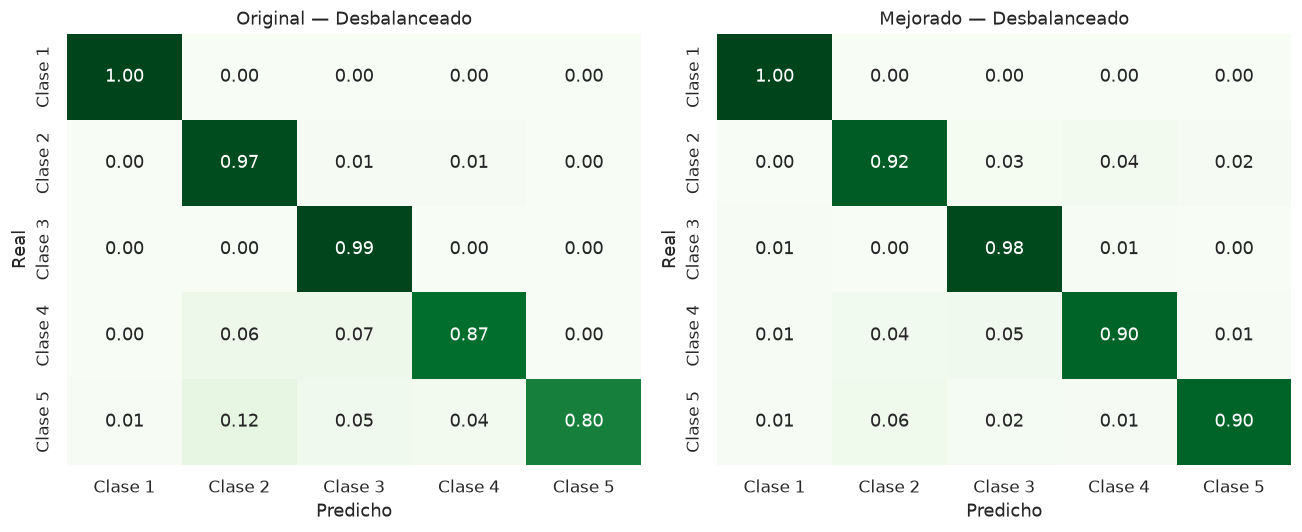

In [73]:
# ----- Matrices de confusión: original vs mejorado (normalizadas por fila) -----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (titulo, y_pred) in zip(axes, [("Original", orig["y_pred"]),
                                       ("Mejorado", y_pred_mej)]):
    cm = confusion_matrix(s["y_te"], y_pred)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens", cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f"{titulo} — {peor_dataset}")
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
plt.tight_layout(); plt.show()

Los pesos asignados son inversamente proporcionales a la frecuencia de cada clase, la 
clase 5 recibe un peso de 10.0 y la clase 4 de 2.5, mientras las mayoritarias tienen 
pesos menores a 1. Esto significa que equivocarse en una clase 5 durante el entrenamiento 
penaliza 10 veces mas que equivocarse en una mayoritaria.

Las clases 4 y 5 mejoran su deteccion, pero las clases 2 y 3 pagan el precio. 
Lo que esta pasando es un intercambio directo: al forzar al modelo a predecir mas 
las clases raras, algunos ejemplos de clase 2 y 3 que antes clasificaba bien ahora 
los manda a clase 4 o 5 por precaucion. La clase 1 no se ve afectada porque ya 
estaba perfecta y ademas tiene el peso mas bajo (0.625).


En conclusion los class weights son utiles si el objetivo es maximizar el recall de 
clases raras sin importar el costo en precision global, pero si el criterio es F1-macro 
esta configuracion no mejora el modelo original.

### 3.2 Sobremuestreo con SMOTE

Otra estrategia frente al desbalance es **sobremuestrear** las clases minoritarias generando
ejemplos sintéticos con SMOTE (solo sobre el conjunto de entrenamiento).

In [ ]:
try:
    from imblearn.over_sampling import SMOTE
    sm = SMOTE(random_state=SixSeven)
    X_tr_sm, y_tr_sm = sm.fit_resample(s["X_tr"], s["y_tr"])
    print("Distribución tras SMOTE:", dict(enumerate(np.bincount(y_tr_sm), start=1)))

    s_sm = dict(s)
    s_sm["X_tr"], s_sm["y_tr"] = X_tr_sm, y_tr_sm

    keras.utils.set_random_seed(SixSeven)
    modelo_smote, _ = entrenar(cfg_peor, s_sm)
    y_pred_sm = modelo_smote.predict(s["X_te"], verbose=0).argmax(axis=1)

    print("\n===== Reporte — MODELO con SMOTE — TEST =====")
    print(classification_report(s["y_te"], y_pred_sm, target_names=CLASS_NAMES,
                                digits=4, zero_division=0))
except ImportError:
    print("imbalanced-learn no está instalado. Descomenta la instalación de la celda 0.")

Distribución tras SMOTE: {1: np.int64(9600), 2: np.int64(9600), 3: np.int64(9600), 4: np.int64(9600), 5: np.int64(9600)}

===== Reporte — MODELO con SMOTE — TEST =====
              precision    recall  f1-score   support

     Clase 1     0.9938    0.9950    0.9944      3200
     Clase 2     0.9772    0.9475    0.9621      2800
     Clase 3     0.9656    0.9813    0.9734      3000
     Clase 4     0.8820    0.9062    0.8940       800
     Clase 5     0.8190    0.8600    0.8390       200

    accuracy                         0.9678     10000
   macro avg     0.9275    0.9380    0.9326     10000
weighted avg     0.9682    0.9678    0.9679     10000



SMOTE queda en el medio: no recupera tanto la Clase 5 como los class weights (0.86 vs 
0.90) pero tampoco destruye tanto las mayoriatrias, por eso el F1-macro cae menos .

Ninguna de las dos tecnicas supera al modelo original en F1-macro, lo que confirma 
que el modelo sin intervencion ya manejaba razonablemente el desbalance, lo que 
cambia con ambas tecnicas es a quien le falla: el original falla en las minoritarias, 
las tecnicas redistribuyen ese error pero no lo eliminan.

La eleccion entre los 3 depende del objetivo: si lo que importa es no perderse ninguna 
postura rara → class weights; si se quiere un balance entre todas las clases → SMOTE; 
si el criterio es F1-macro puro → el modelo original gana.

---
### Declaración de uso de herramientas generativas

Se utilizó asistencia de IA (Claude, Anthropic) con los siguientes propósitos:

- **Visualización de DataFrames:** al llamar `.head()` dos veces en la misma 
  celda, Jupyter solo renderizaba la última tabla.

  prompt: estoy printeando 2 dataset con .head() pero solo se ve el ultimo dataset pero los 2 print muestran los titulos

  solucion: display


- **Inicializacion de parametros del modelo:** al reejecutar el notebook los pesos iniciales 
  de la red cambiaban cada vez, haciendo imposible saber si una mejora 
  se debía al cambio de hiperparámetros o a una inicialización más favorable.

  prompt: hay una forma de hacer un snapshot o algo similar para fijar esos 
  parámetros sin tener que hardcodearlos, porque cada vez que inicio una mlp 
  no sé si mejoré porque es mejor o se inicializó con mejores parámetros

  solucion: seed

- **Partición estratificada del dataset:** al dividir los datos en train/val/test, en algunas pruebas el conjunto de prueba quedaba con una sola clase representada, haciendo imposible evaluar el modelo correctamente.

  prompt: "oye pero al dividir el dataset hice unas pruebas y llegue a testeo con una pura clase, como puedo mantener la distribucion?"

  solución: stratify=y en train_test_split

- **Búsqueda de técnica de regularización alternativa a L2:** conocía L2 pero quería probar otra técnica de regularización para comparar arquitecturas.
  prompt: "que otras formas de regularizacion existen además de l2, la que castigaba los pesos al cuadrado, asi poder hacer una combinatoria de redes mas dispersas entre si, ya que el profe menciono que l2 era el mas comun pero no tan eficiente"

  solución: Dropout (desactiva aleatoriamente neuronas durante el entrenamiento).


- **Adaptación de cross entropy para clasificación multiclase:** en clases se vio cross entropy para clasificación binaria (2 clases), pero el problema tiene 5 clases en la salida.

  prompt: "en clase vimos cross entropy para 2 variables, pero aca tengo 5 variables en la salidaaaaaa como modifico esto help bro"

  solución: sparse_categorical_crossentropy, que es la extensión de cross entropy para múltiples clases

- **Duda sobre certeza en el análisis comparativo de arquitecturas:** al redactar el análisis de las 4 arquitecturas me di cuenta de que no podía concluir con certeza qué elemento específico mejoraba el rendimiento, ya que mi intención al diseñarlas fue abarcar la mayor cantidad de combinaciones posibles, por lo que a cada arquitectura le cambié varios hiperparámetros a la vez.

  prompt1: "mi duda de que estoy haciendo mi analisis y no tengo certeza de la arquitectura que realmente mejora la arquitectura, es por las arquis que eleji que yo queria abarcar la mayor canditad entonces a toas le cambie todo"

  solucion: el problema se llama **variables confundidas** — como cada arquitectura difiere en más de un factor a la vez (activación, optimizer, capas, regularización), no es posible aislar qué elemento específico explica la diferencia.


  prompt2: "entonces tendría que cambiar las arquitecturas y hacer un tipo one vs all para poder tirar factos en mi análisis?"

  solución: el experimento correcto para eso se llama **ablation study** — se parte de una red base y se cambia de a una sola cosa por vez, así se sabe exactamente qué aportó cada decisión.


- **Búsqueda de técnicas para mejorar el modelo con menor desempeño:** necesitaba una estrategia mejorar el performance del peor modelo.

  prompt1: "que metodos existen para mejorar modelos, mantenindo la arquitectura de este, algo para hacerlo mas equilibrado tipo un olchon que absorva esos 90% de control que tienen las clases predominantess"

  solución: sobremuestreo con SMOTE, que genera ejemplos sintéticos de las clases minoritarias.

  prompt2: "pero todos los datos nuevos van a ser tipo perfectos usando la media y eso, recuerda que estoy usando train_test, me va ensuciar la validacion y testeo"

  solución: no existe sesgo siempre que SMOTE se aplique únicamente sobre el conjunto de entrenamiento.
---